# Title Optimization Analysis

This notebook analyzes the results of the iterative title generation process. It evaluates the effectiveness of the LLM-driven optimization by testing several hypotheses related to performance gains, semantic exploration, and optimization trajectories.

In [1]:
# Setup and Dependencies
!pip install -q sentence-transformers

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import drive

drive.mount('/content/drive')

RESULTS_PATH = '/content/drive/MyDrive/numeric_inference_outputs/title_optimization_results.json'
EMBEDDING_MODEL_NAME = 'all-MiniLM-L6-v2'

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

with open(RESULTS_PATH, 'r') as f:
    results = json.load(f)

df = pd.DataFrame(results)
print(f"Loaded {len(df)} optimization results.")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded 20 optimization results.


## Descriptive Statistics: Comparison of Original and Best Optimized Titles

This section compares the original titles with the best optimized titles discovered during the iterative process. For each channel, we display the top titles along with their predicted performance and their values in the 5 most significant PCA dimensions.

In [16]:
# Define additional paths using BASE_PATH
import os
import json
from sklearn.decomposition import PCA
from IPython.display import display

BASE_PATH = '/content/drive/MyDrive/numeric_inference_outputs/'
EVAL_DATA_PATH = os.path.join(BASE_PATH, 'top_significant_channels_eval.json')
TRAIN_DATA_PATH = os.path.join(BASE_PATH, 'train_structured_latest.json')
EMBEDDING_CACHE_PATH = os.path.join(BASE_PATH, 'video_title_embeddings_latest.json')

# Reconstruct PCA for dimension analysis
with open(TRAIN_DATA_PATH, 'r') as f:
    train_data = json.load(f)
with open(EMBEDDING_CACHE_PATH, 'r') as f:
    embedding_cache = json.load(f)

all_train_embeddings = []
for channel in train_data:
    for video in channel['videos']:
        if video['title'] in embedding_cache:
            all_train_embeddings.append(embedding_cache[video['title']])

X_train = np.array(all_train_embeddings)
pca_reconstructed = PCA(n_components=15, random_state=42)
pca_reconstructed.fit(X_train)

with open(EVAL_DATA_PATH, 'r') as f:
    eval_dataset = json.load(f)

def get_top_5_dims(channel_name, eval_dataset):
    channel_data = next(c for c in eval_dataset if c['channel_name'].lower() == channel_name.lower())
    coeffs = np.abs(channel_data['model']['coefficients'])
    top_5_indices = np.argsort(coeffs)[-5:][::-1]
    return top_5_indices

def create_comparison_tables(df, eval_dataset, pca, embedding_model):
    channels = df['channel'].unique()

    for channel in channels:
        print(f"### Channel: {channel}")
        top_5_dims = get_top_5_dims(channel, eval_dataset)

        channel_df = df[df['channel'] == channel]

        # Original Titles Table
        orig_data = []
        for _, row in channel_df.iterrows():
            channel_eval = next(c for c in eval_dataset if c['channel_name'].lower() == channel.lower())
            video_eval = next(v for v in channel_eval['test_videos'] if v['video_id'] == row['video_id'])
            real_views = video_eval['actual_views']

            emb = embedding_model.encode([row['original_title']])
            proj = pca.transform(emb)[0]

            res = {
                'Title': row['original_title'],
                'Real Views': real_views,
                'Pred Score': f"{row['original_score']:.4f}"
            }
            for d in top_5_dims:
                res[f'Dim {d}'] = f"{proj[d]:.4f}"
            orig_data.append(res)

        print("#### Original Titles")
        display(pd.DataFrame(orig_data))

        # Best Optimized Titles Table
        best_data = []
        for _, row in channel_df.iterrows():
            emb = embedding_model.encode([row['best_optimized_title']])
            proj = pca.transform(emb)[0]

            res = {
                'Title': row['best_optimized_title'],
                'Pred Score': f"{row['best_optimized_score']:.4f}",
                'Improvement': f"{row['improvement']:.4f}"
            }
            for d in top_5_dims:
                res[f'Dim {d}'] = f"{proj[d]:.4f}"
            best_data.append(res)

        print("#### Best Optimized Titles")
        display(pd.DataFrame(best_data))

create_comparison_tables(df, eval_dataset, pca_reconstructed, embedding_model)

### Channel: a16z
#### Original Titles


,Title,Real Views,Pred Score,Dim 3,Dim 1,Dim 12,Dim 2,Dim 9
0,Udio: From Text to Tune,2990,8.0034,-0.1132,-0.0055,0.0272,0.0515,-0.1830
1,Marc Andreessen & Amjad Masad on “Good Enough”...,45118,10.7171,0.1223,0.1096,-0.0610,-0.0939,-0.1591
2,The 2045 Superintelligence Timeline: Epoch AI’...,6765,8.8197,-0.0188,0.3462,-0.0274,-0.0375,0.0431
3,AI & The Future of Modern Warfare,7973,8.9839,-0.0392,0.3491,-0.0062,0.0477,-0.1074
4,"Mark Cuban on the NBA, Cost Plus Drugs, and Ho...",3686,8.2126,0.1025,-0.2315,-0.0721,0.1486,0.0350
5,Truth Terminal - The AI Bot That Became a Cryp...,94035,11.4514,-0.0601,0.1896,-0.0057,-0.1159,0.1191
6,GPT-5 and Agents Breakdown – w/ OpenAI Researc...,15514,9.6496,0.0697,0.0401,0.1284,0.0342,-0.1620
7,How to Enable a Manufacturing Renaissance,4997,8.5168,-0.1483,-0.0017,0.0441,-0.1522,0.0014
8,Reasoning Models Are Remaking Professional Ser...,10250,9.2351,-0.1203,-0.0974,0.1215,-0.0602,-0.2216
9,JD Vance on the Future of America,3417,8.1368,0.2374,-0.0579,0.1375,0.2040,-0.0398


#### Best Optimized Titles


,Title,Pred Score,Improvement,Dim 3,Dim 1,Dim 12,Dim 2,Dim 9
0,Udio CEO: How AI is Orchestrating the Next $10...,10.4334,2.4300,0.2180,0.1977,-0.1904,-0.3234,0.0488
1,"Marc Andreessen: Why ""Good Enough"" AI Is a Thr...",10.2478,-0.4692,0.1111,0.3363,-0.0700,-0.1603,0.0785
2,The Singularity Race: Why America Must Own the...,10.1719,1.3523,0.1102,0.4235,0.0721,-0.1266,0.1014
3,From Silicon Valley to the Frontline: The AI R...,10.1394,1.1554,0.0375,0.3704,-0.0549,-0.1509,0.0553
4,Mark Cuban on How AI and Big Pharma Are Colliding,9.7882,1.5756,0.1718,0.2375,-0.0250,0.0176,0.0396
5,Truth Terminal: Why the Next Billion-Dollar St...,10.0598,-1.3916,-0.0102,0.3622,-0.0309,-0.2557,0.1247
6,The AI Agent Takeover: Why the Next 24 Months ...,10.6944,1.0449,0.2202,0.3509,-0.0852,-0.2501,0.0770
7,The Hardware Renaissance: Why Top Founders are...,10.4287,1.9119,0.0948,0.2682,0.0030,-0.3386,0.1093
8,Why Silicon Valley’s Next AI Target Is the $5 ...,9.8940,0.6589,0.0388,0.2457,-0.0096,-0.3053,0.0927
9,JD Vance: The Strategy to Break China’s AI Dom...,10.3038,2.1670,0.1901,0.2969,0.0283,-0.0890,0.2181


### Channel: 20VC with Harry Stebbings
#### Original Titles


,Title,Real Views,Pred Score,Dim 3,Dim 5,Dim 2,Dim 14,Dim 0
0,Joey Zwillinger: From $4.1BN to $142M Market C...,3529,8.1691,0.1858,-0.0546,-0.0611,0.0255,-0.2468
1,"Plural Partner, Taavet Hinrikus: Why Founders ...",8151,9.0060,0.1947,0.0188,-0.1284,0.0762,-0.2453
2,Arthur Mensch: Open vs Closed - Who Wins and M...,11919,9.3860,0.1950,-0.0151,0.1923,0.1361,0.1170
3,Stable Diffusion Creator Analyzes the OpenAI-M...,496,6.2086,0.0547,-0.1026,-0.1371,-0.0346,0.1167
4,Snap's VP of Product Jack Brody: The Future of...,3076,8.0317,0.1194,-0.1198,0.0476,-0.0456,0.1324
5,"Sridhar Ramaswamy, CEO @Snowflake: Deepseek is...",19902,9.8986,0.0934,-0.0303,0.0483,-0.1943,0.1523
6,How I Became the Head of Instagram -- Adam Mos...,1079,6.9847,0.0446,-0.1884,-0.0357,-0.1300,0.2021
7,"Julian Teixeira, CRO @ 1Password: How to Hire ...",6314,8.7507,-0.0547,0.0513,-0.2244,-0.0606,0.0615
8,Kevin Egan: Biggest Lesson on Managing Sales T...,1541,7.3408,0.1272,0.0825,-0.2092,0.1105,0.0121
9,David Meyer: Why You Should Hire People Who Ar...,6319,8.7515,0.1020,0.0356,-0.1989,0.0351,0.0882


#### Best Optimized Titles


,Title,Pred Score,Improvement,Dim 3,Dim 5,Dim 2,Dim 14,Dim 0
0,$4BN Valuation to $142M: Joey Zwillinger on th...,8.5842,0.4152,0.1983,-0.1209,-0.1407,0.0307,-0.2836
1,Taavet Hinrikus: Why Multi-Stage VC Funds Are ...,8.3180,-0.6880,0.1422,0.0562,-0.1853,0.0217,-0.1933
2,Mistral CEO Arthur Mensch: Why Open Source Wil...,9.2513,-0.1347,0.2313,-0.0306,-0.2462,0.0345,0.1615
3,The Microsoft-OpenAI Fracture: Emad Mostaque o...,9.3192,3.1106,0.1528,0.0012,-0.2480,0.0410,0.3065
4,The Future of Computing: Snap VP Jack Brody on...,8.9208,0.8891,0.0228,-0.0854,-0.1852,0.0217,0.2836
5,Snowflake CEO Sridhar Ramaswamy: OpenAI vs. An...,9.2602,-0.6384,0.1886,0.0599,-0.2940,-0.1508,0.2397
6,Adam Mosseri: Why You Should Not Build an AI S...,9.0268,2.0421,0.0394,0.0048,-0.4012,0.0713,0.3753
7,The Truth About Hiring Sales Reps: Why Most Ea...,7.4074,-1.3432,0.1537,0.1427,-0.2393,0.0739,-0.1251
8,From Seed to $1BN: The Exact Sales Playbook of...,8.3366,0.9957,0.0536,-0.0755,-0.2860,-0.0112,-0.1387
9,David Meyer: How to Spot the Founders Who Will...,8.6414,-0.1101,0.2190,-0.1266,-0.3345,0.0969,-0.1571


## Optimization Trajectory: Average Improvement per Iteration

We analyze how much the predicted views improve at each step of the iterative process. This helps us understand the efficiency of the feedback loop and whether the gains diminish over time.

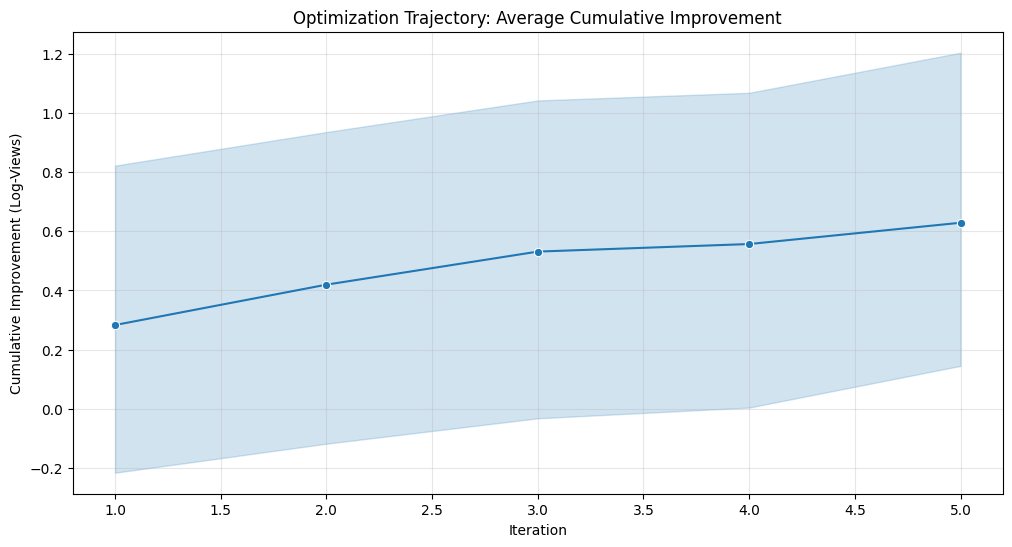

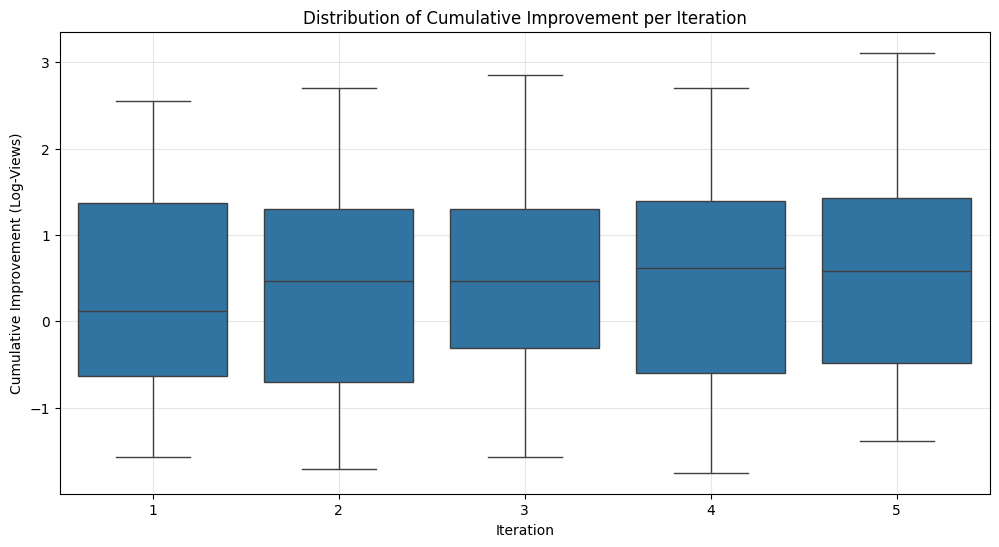

Average Gain per Iteration step:
iteration
1    0.282958
2    0.136481
3    0.111789
4    0.025559
5    0.071969
Name: improvement, dtype: float64


In [17]:
iter_progress = []
for idx, row in df.iterrows():
    baseline = row['original_score']
    for iter_data in row['history']:
        it = iter_data['iteration']
        best_in_iter = max(t['score'] for t in iter_data['titles'])
        iter_progress.append({
            'video_id': row['video_id'],
            'iteration': it,
            'best_score': best_in_iter,
            'improvement': best_in_iter - baseline
        })

iter_df = pd.DataFrame(iter_progress)

plt.figure(figsize=(12, 6))
sns.lineplot(data=iter_df, x='iteration', y='improvement', marker='o')
plt.title('Optimization Trajectory: Average Cumulative Improvement')
plt.xlabel('Iteration')
plt.ylabel('Cumulative Improvement (Log-Views)')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=iter_df, x='iteration', y='improvement')
plt.title('Distribution of Cumulative Improvement per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cumulative Improvement (Log-Views)')
plt.grid(True, alpha=0.3)
plt.show()

avg_step_gain = iter_df.groupby('iteration')['improvement'].mean().diff().fillna(iter_df[iter_df['iteration']==1]['improvement'].mean())
print("Average Gain per Iteration step:")
print(avg_step_gain)

## Hypothesis 1: Lower starting performance leads to greater potential for improvement

### Methodology
We compare the predicted log-views of the original title (baseline) against the absolute improvement achieved after 5 iterations. We use Pearson correlation to determine if there is a significant negative relationship between the starting point and the gain.

### Hypotheses
- **Null Hypothesis (H0)**: There is no correlation between the original title's predicted performance and the improvement gained through optimization.
- **Alternative Hypothesis (H1)**: There is a negative correlation; titles with lower initial scores show larger improvements.

### Results

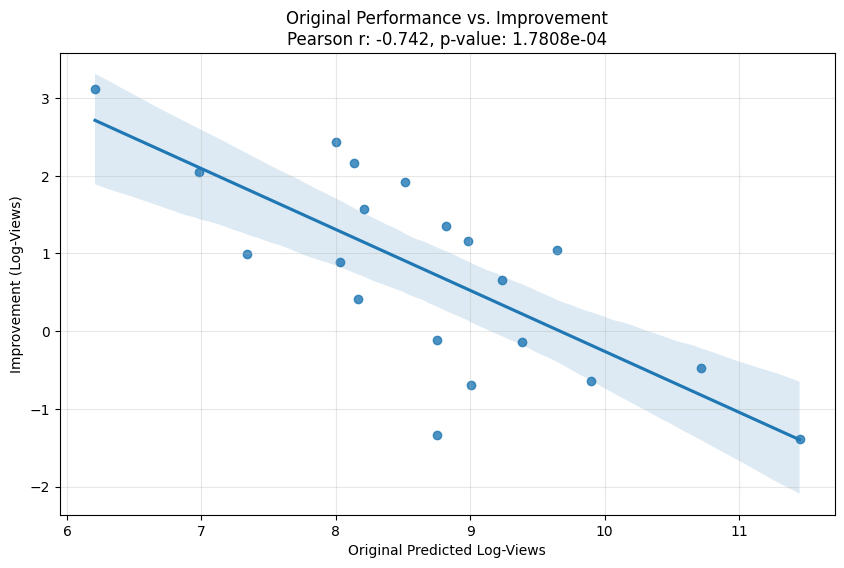

Mean Improvement: 0.7487
Max Improvement: 3.1106
Min Improvement: -1.3916


In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='original_score', y='improvement')

r, p = stats.pearsonr(df['original_score'], df['improvement'])
plt.title(f'Original Performance vs. Improvement\nPearson r: {r:.3f}, p-value: {p:.4e}')
plt.xlabel('Original Predicted Log-Views')
plt.ylabel('Improvement (Log-Views)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean Improvement: {df['improvement'].mean():.4f}")
print(f"Max Improvement: {df['improvement'].max():.4f}")
print(f"Min Improvement: {df['improvement'].min():.4f}")

### Interpretation
If the correlation is significantly negative (p < 0.05), it suggests a 'ceiling effect' or 'regression to the mean' where titles that are already performing well have less room for optimization compared to those that start with poor semantic alignment with channel success drivers.

## Hypothesis 2: Greater semantic exploration leads to higher relative improvement

### Methodology
We calculate the semantic distance (1 - Cosine Similarity) between the original title and the best optimized title. We then correlate this distance with the improvement achieved. This tests whether 'bolder' changes in the title's meaning lead to better outcomes.

### Hypotheses
- **Null Hypothesis (H0)**: Semantic distance from the original title does not correlate with performance improvement.
- **Alternative Hypothesis (H1)**: Greater semantic distance from the original title correlates positively with performance improvement.

### Results

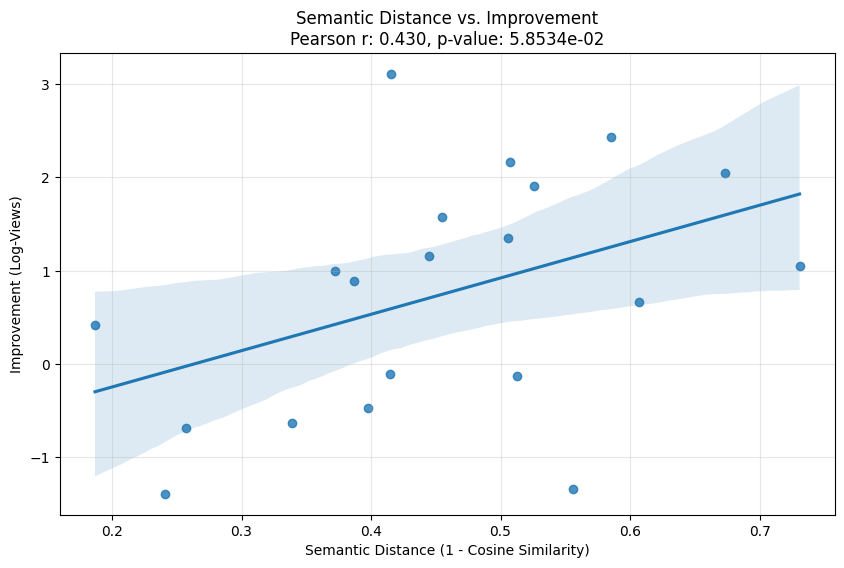

In [19]:
# Calculate embeddings for distance analysis
orig_titles = df['original_title'].tolist()
best_titles = df['best_optimized_title'].tolist()

orig_embs = embedding_model.encode(orig_titles)
best_embs = embedding_model.encode(best_titles)

distances = []
for i in range(len(df)):
    sim = cosine_similarity(orig_embs[i].reshape(1, -1), best_embs[i].reshape(1, -1))[0][0]
    distances.append(1 - sim)

df['semantic_distance'] = distances

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='semantic_distance', y='improvement')

r, p = stats.pearsonr(df['semantic_distance'], df['improvement'])
plt.title(f'Semantic Distance vs. Improvement\nPearson r: {r:.3f}, p-value: {p:.4e}')
plt.xlabel('Semantic Distance (1 - Cosine Similarity)')
plt.ylabel('Improvement (Log-Views)')
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation
A positive correlation indicates that the optimization process benefits from exploring regions of the semantic space farther from the original title. This would suggest that the LLM is effectively 'pivoting' the content to better match high-performance patterns.

## Hypothesis 3: Semantic optimization translates to performance via targeted hill-climbing

### Methodology
To test if the model is effectively 'learning' from feedback, we analyze the semantic trajectory across iterations. For each iteration $i$, we measure the average distance of its suggestions to the **best** performing suggestion of iteration $i-1$ vs. the **worst** performing suggestion of iteration $i-1$.

We expect the suggestions in iteration $i$ to gravitate towards previous 'successes' and move away from previous 'failures'.

### Hypotheses
- **Null Hypothesis (H0)**: Subsequent suggestions do not show a semantic bias toward previous high-performing titles.
- **Alternative Hypothesis (H1)**: Suggestions in later iterations are semantically closer to previous best-performers than to previous worst-performers.

### Results

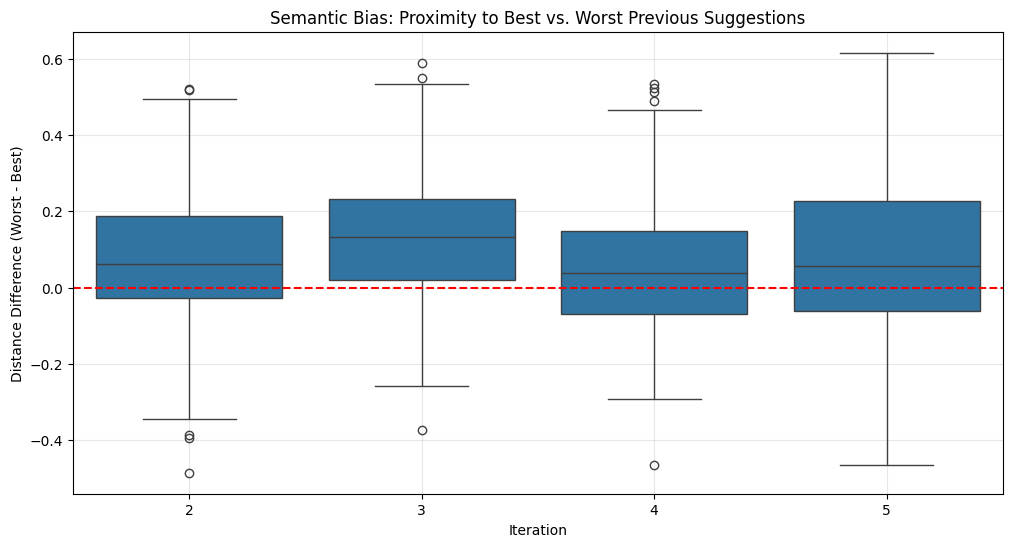

Mean Relative Proximity by Iteration (Positive = Closer to Best):
iteration
2    0.078410
3    0.129702
4    0.052311
5    0.065836
Name: relative_proximity, dtype: float32


In [20]:
trajectory_data = []

for idx, row in df.iterrows():
    history = row['history']
    for i in range(1, len(history)): # Start from iteration 2 (index 1)
        prev_titles = history[i-1]['titles']
        prev_titles_sorted = sorted(prev_titles, key=lambda x: x['score'], reverse=True)

        best_prev_text = prev_titles_sorted[0]['text']
        worst_prev_text = prev_titles_sorted[-1]['text']

        curr_titles = [t['text'] for t in history[i]['titles']]

        # Embeddings
        best_prev_emb = embedding_model.encode([best_prev_text])
        worst_prev_emb = embedding_model.encode([worst_prev_text])
        curr_embs = embedding_model.encode(curr_titles)

        # Distances
        dist_to_best = 1 - cosine_similarity(curr_embs, best_prev_emb).flatten()
        dist_to_worst = 1 - cosine_similarity(curr_embs, worst_prev_emb).flatten()

        for d_b, d_w in zip(dist_to_best, dist_to_worst):
            trajectory_data.append({
                'video_id': row['video_id'],
                'iteration': i + 1,
                'dist_to_best_prev': d_b,
                'dist_to_worst_prev': d_w,
                'relative_proximity': d_w - d_b # Positive means closer to best than to worst
            })

traj_df = pd.DataFrame(trajectory_data)

plt.figure(figsize=(12, 6))
sns.boxplot(data=traj_df, x='iteration', y='relative_proximity')
plt.axhline(0, color='red', linestyle='--')
plt.title('Semantic Bias: Proximity to Best vs. Worst Previous Suggestions')
plt.ylabel('Distance Difference (Worst - Best)')
plt.xlabel('Iteration')
plt.grid(True, alpha=0.3)
plt.show()

print("Mean Relative Proximity by Iteration (Positive = Closer to Best):")
print(traj_df.groupby('iteration')['relative_proximity'].mean())

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=traj_df, x='dist_to_best_prev', label='Distance to Best Prev', fill=True)
sns.kdeplot(data=traj_df, x='dist_to_worst_prev', label='Distance to Worst Prev', fill=True)
plt.title('Distribution of Semantic Distances to Previous Best/Worst')
plt.xlabel('Distance (1 - Cosine Similarity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

t_stat, p_val = stats.ttest_rel(traj_df['dist_to_best_prev'], traj_df['dist_to_worst_prev'])
print(f"Paired t-test between dist_to_best and dist_to_worst:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")

### Interpretation
The boxplot shows the distribution of `(Distance to Worst) - (Distance to Best)`. Values above 0 indicate the suggestion is semantically closer to the previous iteration's best performer.

If the distribution is significantly shifted above zero (confirmed by the t-test), it proves that the LLM is successfully hill-climbing in the semantic space, using the feedback to converge on high-performance clusters.

## Hypothesis 4: Greater semantic coverage correlates with higher improvement

### Methodology
We measure the "Explored Area Volume" or "Semantic Coverage" of the optimization process for each video. This is computed as the **Sum of Variances** across the first 5 PCA dimensions of all titles generated during the 5 iterations.

### Hypotheses
- **Null Hypothesis (H0)**: The semantic breadth of the exploration (coverage) does not correlate with the final improvement achieved.
- **Alternative Hypothesis (H1)**: Videos where the LLM explores a broader semantic area achieve higher improvement.

### Results

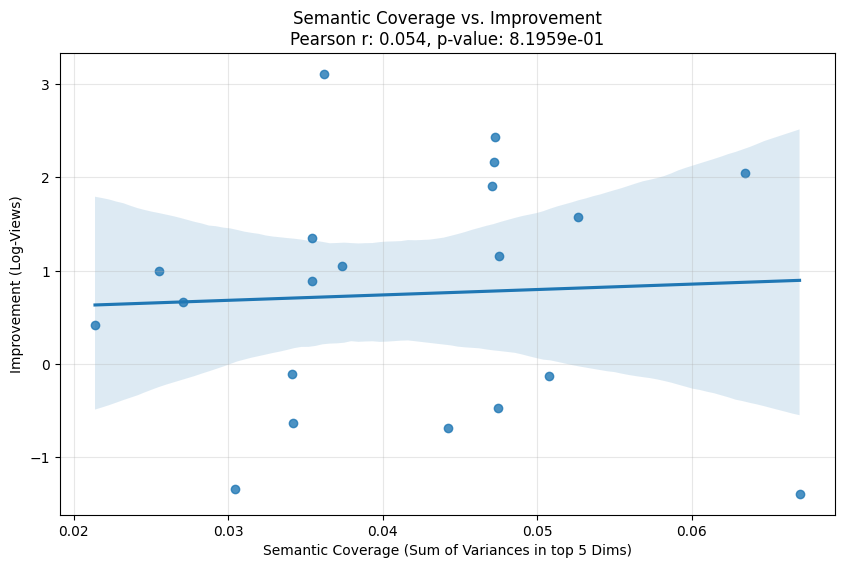

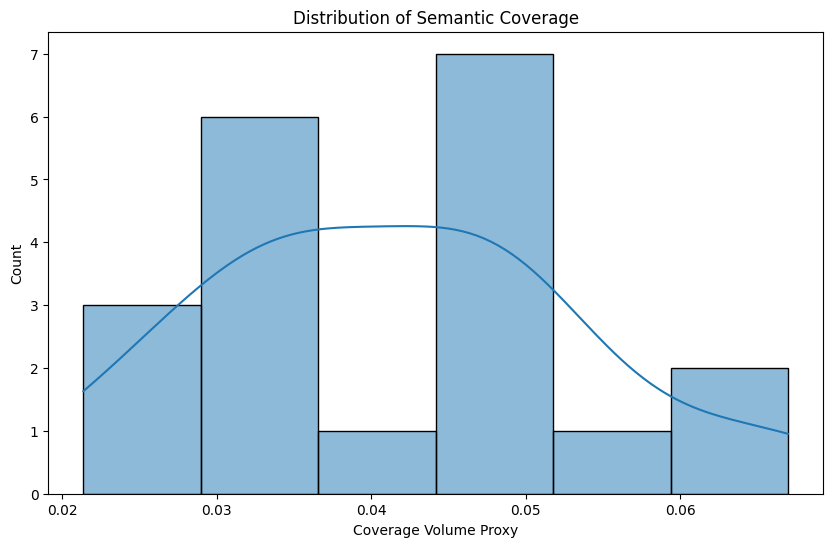

In [21]:
coverage_data = []
for idx, row in df.iterrows():
    all_titles = []
    for it in row['history']:
        all_titles.extend([t['text'] for t in it['titles']])

    embs = embedding_model.encode(all_titles)
    projs = pca_reconstructed.transform(embs)

    variances = np.var(projs[:, :5], axis=0)
    coverage = np.sum(variances)

    coverage_data.append({
        'video_id': row['video_id'],
        'coverage': coverage,
        'improvement': row['improvement']
    })

cov_df = pd.DataFrame(coverage_data)

plt.figure(figsize=(10, 6))
sns.regplot(data=cov_df, x='coverage', y='improvement')
r, p = stats.pearsonr(cov_df['coverage'], cov_df['improvement'])
plt.title(f'Semantic Coverage vs. Improvement\nPearson r: {r:.3f}, p-value: {p:.4e}')
plt.xlabel('Semantic Coverage (Sum of Variances in top 5 Dims)')
plt.ylabel('Improvement (Log-Views)')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(cov_df['coverage'], kde=True)
plt.title('Distribution of Semantic Coverage')
plt.xlabel('Coverage Volume Proxy')
plt.show()

### Interpretation
A positive correlation would suggest that 'broad exploration' is beneficial for identifying high-performance title clusters. Divergent thinking in the title generation phase allows the LLM to test more varied semantic strategies, increasing the probability of discovering a highly effective title.